In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn import model_selection
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [164]:
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(data.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  

In [165]:
for col in data.columns:
    if data[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [166]:
data.shape

(1470, 35)

In [167]:
data.drop(columns=["Over18",'EmployeeCount', 'EmployeeNumber','StandardHours'], inplace=True) #we will drop employeenumber also because it is just an id assigned to the employee

In [168]:
data.shape

(1470, 31)

In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [170]:
data.select_dtypes(include=['object']).dtypes #to find which features contains non numeric values

Attrition         object
BusinessTravel    object
Department        object
EducationField    object
Gender            object
JobRole           object
MaritalStatus     object
OverTime          object
dtype: object

In [171]:
data['Attrition'] = data['Attrition'].map({'Yes': 1, 'No': 0})

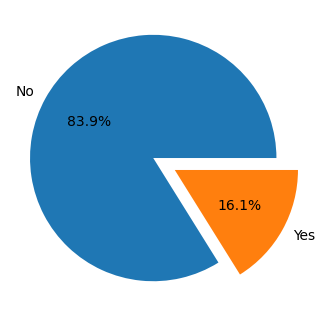

In [172]:
plt.figure(figsize=(4,4))
pie = data.groupby('Attrition')['Attrition'].count()
plt.pie(pie, explode=[0.1, 0.1], labels=['No', 'Yes'], autopct='%1.1f%%');

In [173]:
# Columns that droped by seeing feature importance curve and analyzing classification report.
# you can comment out this block at first,and see step by step again commenting in to see improvement of model
data.drop(columns=['Department','EducationField','MaritalStatus','HourlyRate','JobLevel','PerformanceRating','MonthlyRate','DailyRate'], inplace=True)

print(data.shape)

(1470, 23)


In [174]:
# Seperate category/text and Numerical Columns 
categorical_columns = []
numerical_columns = []
for col in data:
    if data[col].dtype == object:
        categorical_columns.append(col)
    else :
        numerical_columns.append(col)

numerical_columns.remove("Attrition")                        # Beacause, it is target.
print(categorical_columns)
print(numerical_columns)

['BusinessTravel', 'Gender', 'JobRole', 'OverTime']
['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [175]:
# Features and Target selection
features = numerical_columns + categorical_columns

X = data[features]
y = data['Attrition'].values                                    # .values → converts the pandas column to a NumPy array

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2,random_state= 42)

In [176]:
def one_hot_encode(train, test, column_name):
    # Encode only the given column, preserve all other columns
    train_encoded = pd.get_dummies(train, columns=[column_name], drop_first=True)
    test_encoded = pd.get_dummies(test, columns=[column_name], drop_first=True)
    
    # Align columns to avoid mismatch between train and test
    test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)
    
    return train_encoded, test_encoded

# Encode Categorical Columns
for col in categorical_columns:
    X_train, X_test = one_hot_encode(X_train, X_test, col)
print(X_train.shape,X_test.shape)

(1176, 30) (294, 30)


In [177]:
print("y_test -->")
print(f'0s : {y_test.shape[0] - np.count_nonzero(y_test)}')
print(f'1s : {np.count_nonzero(y_test)}')
# Both classes are not well balanced.Thus Accuracy will not give "Perfect" tag to the model
# we have to compute mode based on precision and recall(mainly recall for this example)

y_test -->
0s : 255
1s : 39


In [178]:
# Scale the features(Scaling does matter much in logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)


# APPLYING THRESHOLD TO INCREASE RECALL

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]                 # it will give predicted probabilities for class 1
threshold = 0.15                                                       # Apply threshold
y_pred_custom = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.77      0.85       255
           1       0.33      0.74      0.46        39

    accuracy                           0.77       294
   macro avg       0.64      0.76      0.65       294
weighted avg       0.87      0.77      0.80       294



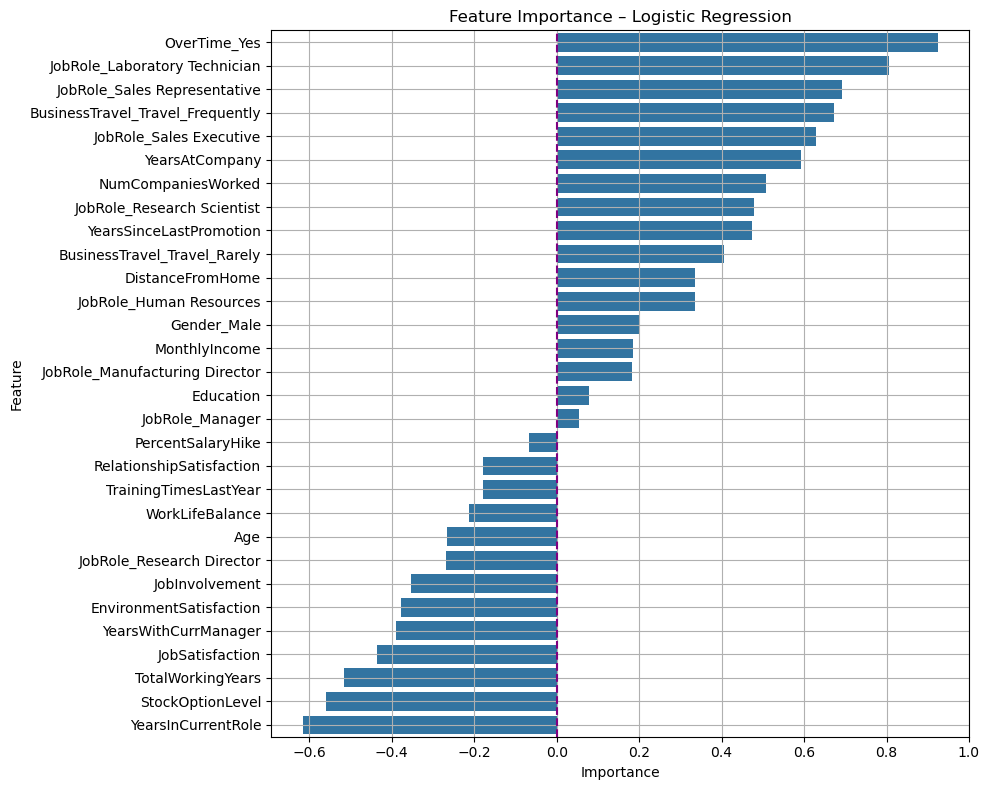

In [179]:
# Get feature importance (coefficients)
importance = log_model.coef_[0]  # for binary classification

# Combine with feature names
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort by absolute importance
feature_importance['AbsImportance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='AbsImportance', ascending=False)

# Drop the helper column
feature_importance.drop(columns='AbsImportance', inplace=True)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.sort_values(by='Importance', ascending=False),
    x='Importance',
    y='Feature'
)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(0, color='purple', linestyle='--')
plt.tight_layout()
plt.grid(True)
plt.title("Feature Importance – Logistic Regression")
plt.show()
